# Bayesian 기반 도로(차선 영역) 분류 예제

이 코드는 2026년 성신여자대학교 자율이동체시스템 수업에서 사용하기 위해 만든 코드입니다. KITTI 데이터셋의 흑백 이미지 프레임을 이용하여 도로 영역(road)과 배경(background)을 구분하는 간단한 Bayesian 분류기를 구현하였습니다. 복잡한 딥러닝 모델 없이도, 픽셀 밝기 분포와 확률 모델만으로 도로를 추정하는 기본적인 아이디어를 이해하는 데 목적이 있습니다.

## 1. 도로 검출

전체적인 동작 과정은 다음과 같습니다.

먼저, 이미지에서 도로가 존재할 가능성이 높은 영역을 사다리꼴 형태로 가정합니다. 이는 카메라 영상에서 도로가 아래쪽에서 넓고 위쪽으로 갈수록 좁아지며, 소실점 방향으로 수렴한다는 기하학적 특성을 이용한 것입니다. 이 영역은 도로 후보(road), 그 외 영역은 배경(background)으로 간주합니다.

그 다음, 각 프레임에 대해 도로 영역과 배경 영역에서 픽셀 밝기 히스토그램을 각각 계산합니다. 이 히스토그램은 “도로일 때 특정 밝기 값이 나올 확률”과 “배경일 때 특정 밝기 값이 나올 확률”을 근사하는 역할을 합니다. 이때 Laplace smoothing을 적용하여 확률이 0이 되는 문제를 방지합니다.

이후 Bayesian 분류 원리를 이용하여 각 픽셀에 대해 다음을 계산합니다.
  - 해당 픽셀이 도로일 확률
  - 해당 픽셀이 배경일 확률

두 값을 비교하여 더 큰 쪽으로 분류하면 MAP (Maximum A Posteriori) 기반 이진 마스크가 생성됩니다.

또한 이 코드는 단일 프레임만 사용하는 것이 아니라, 이전 프레임의 통계 정보를 일정 비율로 유지하면서 현재 프레임과 결합하는 방식으로 시계열 일관성(temporal consistency)을 반영합니다. 이를 통해 프레임 간 노이즈를 줄이고 더 안정적인 결과를 얻을 수 있습니다.

최종적으로 다음과 같은 결과를 생성합니다.
  - mask_XXXXXX.png : 도로(255) / 배경(0)으로 구성된 이진 마스크
  - overlay_XXXXXX.png : 원본 영상 위에 도로 영역을 빨간색으로 표시한 결과
  - prob_XXXXXX.png : 각 픽셀이 도로일 확률을 나타낸 그레이스케일 이미지

이 예제는 차선 검출이나 자율주행 인식에서 사용되는 복잡한 모델의 기초 개념을 이해하기 위한 출발점으로 활용할 수 있으며, 이후 Hough Transform, CNN 기반 segmentation 등으로 확장해 볼 수 있습니다.

In [3]:
"""
Minimal Bayesian road-vs-background classifier for KITTI grayscale frames.

Assumptions
-----------
- Images are KITTI odometry grayscale frames (image_0) sized 1241x376.
- Road pixels appear mostly in a bottom trapezoid; background near top band.
- Uses 1D intensity histograms with Laplace smoothing to estimate likelihoods.

Usage
-----
    --data-root dataset/sequences/00/image_0 \
    --train-frames 80 \
    --save-frames 10 \
    --out-dir outputs/bayes_road

Outputs
-------
- <out-dir>/mask_XXXXXX.png     : binary MAP mask (road=255, bg=0)
- <out-dir>/overlay_XXXXXX.png  : red overlay of road mask on original frame
- <out-dir>/prob_XXXXXX.png     : grayscale probability map (0-255)
"""
#!/usr/bin/env python3
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)
    
    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape
    
    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주
    
    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)
        
        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)
        
        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=Path, default=Path("E:/KITTI_dataset/dataset/sequences/09/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=10, help="frames to save; -1 for all")
    parser.add_argument("--out-dir", type=Path, default=Path("E:/results/bayes_road_09"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    args = parser.parse_args(args=[])
    
    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )


Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency


## 문제 1. Projection Matrix 해석

카메라의 Projection Matrix는 3차원 공간에 있는 점을 2차원 이미지 좌표로 변환하기 위해 사용되는 행렬이다. 즉, 실제 공간에 존재하는 물체의 위치를 카메라 이미지 위의 픽셀 위치로 나타내기 위한 과정에서 사용된다.

일반적으로 Projection Matrix P는 다음과 같이 표현할 수 있다.

$$
P = K [R | t]
$$

여기서 K는 카메라 내부 파라미터를 나타내는 intrinsic matrix이고, R과 t는 카메라의 위치와 방향을 나타내는 extrinsic parameter이다. KITTI 데이터셋에서 제공되는 Projection Matrix는 3×4 형태이며, 3차원 점을 이미지 평면의 픽셀 좌표로 투영하는 데 사용된다.

---

### 1. Intrinsic Parameters

Intrinsic parameter는 카메라 내부의 특성을 나타내는 값이다. 대표적으로 초점 거리와 이미지 중심점이 포함된다.

$$
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}
$$

fx와 fy는 카메라의 초점 거리를 의미하며, 픽셀 단위로 표현된다. 이 값들은 3차원 공간의 점이 이미지에서 얼마나 크게 보이는지를 결정한다.

cx와 cy는 이미지 평면에서의 중심점, 즉 principal point를 의미한다. 이는 카메라의 광축이 이미지 평면과 만나는 지점으로 볼 수 있으며, 투영된 점이 이미지 안에서 어느 위치에 나타나는지에 영향을 준다.

따라서 intrinsic parameter는 3차원 점을 이미지 평면으로 투영할 때 크기, 위치, 중심점을 결정하는 역할을 한다.

---

### 2. Extrinsic Parameters

Extrinsic parameter는 카메라 외부의 정보를 나타내며, 카메라가 공간상에서 어떤 위치에 있고 어떤 방향을 바라보고 있는지를 설명한다.

R은 회전 행렬로, 월드 좌표계의 점을 카메라가 바라보는 방향에 맞게 회전시키는 역할을 한다.

t는 이동 벡터로, 월드 좌표계와 카메라 좌표계 사이의 위치 차이를 나타낸다.

즉, R과 t는 월드 좌표계에 있는 3차원 점을 카메라 좌표계 기준으로 변환하기 위해 사용된다. 이후 intrinsic parameter가 적용되면서 해당 점이 이미지 평면 위의 픽셀 좌표로 투영된다.

---

### 3. 3D에서 2D로 투영되는 과정

3차원 점 X가 다음과 같이 주어졌다고 하면,

$$
X = (X, Y, Z, 1)^T
$$

Projection Matrix P를 곱하여 이미지 평면상의 동차 좌표를 얻을 수 있다.

$$
\begin{bmatrix}
u_h \\
v_h \\
w_h
\end{bmatrix}
=
P
\begin{bmatrix}
X \\
Y \\
Z \\
1
\end{bmatrix}
$$

이때 바로 얻어지는 값은 실제 픽셀 좌표가 아니라 동차 좌표이므로, 마지막 값인 wh로 나누어 정규화해야 한다.

$$
u = \frac{u_h}{w_h}, \quad
v = \frac{v_h}{w_h}
$$

이 과정을 통해 3차원 공간의 점은 이미지 평면상의 픽셀 좌표 u, v로 변환된다.

이러한 투영 과정은 원근 투영의 특성을 가진다. 따라서 카메라에서 가까운 물체는 이미지에서 크게 보이고, 멀리 있는 물체는 작게 보인다. 또한 실제 공간에서 평행한 도로 차선도 이미지에서는 위쪽으로 갈수록 서로 가까워지며, 결국 소실점 방향으로 수렴하는 형태로 나타난다.

## 문제 2  Projection Matrix를 이용한 3D → 2D 투영

Projection Matrix P0:
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]


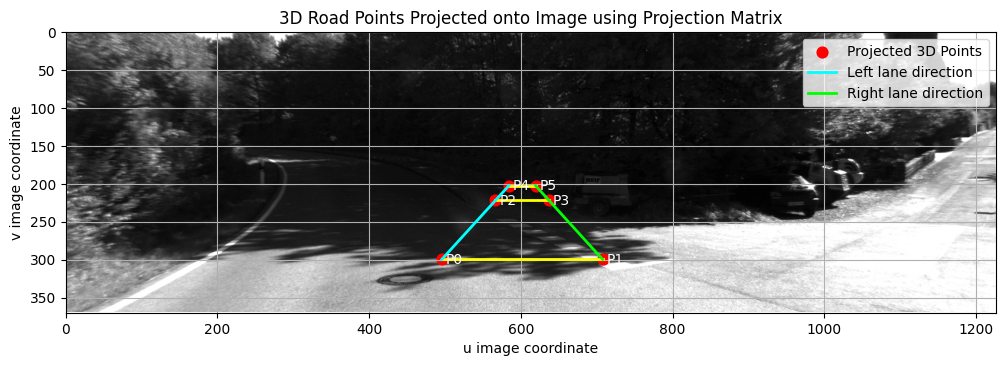

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 경로 설정
calib_path = "E:/KITTI_dataset/dataset/sequences/09/calib.txt"
image_path = "E:/KITTI_dataset/dataset/sequences/09/image_0/000000.png"

# calib.txt에서 Projection Matrix 읽기
def read_projection_matrix(calib_path, camera="P0"):
    with open(calib_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith(camera + ":"):
            values = line.strip().split()[1:]
            P = np.array(values, dtype=np.float64).reshape(3, 4)
            return P

    raise ValueError(f"{camera} not found in calib.txt")

P = read_projection_matrix(calib_path, camera="P0")

print("Projection Matrix P0:")
print(P)

# 도로 바닥에 나열된 3D 점들
# X: 좌우 방향, Y: 지면 높이, Z: 카메라 전방 거리
points_3D = np.array([
    [-1.5, 1.65, 10, 1],
    [ 1.5, 1.65, 10, 1],
    [-1.5, 1.65, 30, 1],
    [ 1.5, 1.65, 30, 1],
    [-1.5, 1.65, 60, 1],
    [ 1.5, 1.65, 60, 1]
])

# 3D → 2D 투영
projected = P @ points_3D.T

# homogeneous coordinate 정규화
u = projected[0] / projected[2]
v = projected[1] / projected[2]

# 이미지 불러오기
img = Image.open(image_path)

# 이미지 위에 투영 결과 시각화
plt.figure(figsize=(12, 5))
plt.imshow(img, cmap="gray")

plt.scatter(u, v, c="red", s=60, label="Projected 3D Points")

# 가까운 점끼리, 중간 점끼리, 먼 점끼리 연결
for i in range(0, len(points_3D), 2):
    plt.plot([u[i], u[i+1]], [v[i], v[i+1]], c="yellow", linewidth=2)

# 왼쪽 차선 방향, 오른쪽 차선 방향 연결
plt.plot([u[0], u[2], u[4]], [v[0], v[2], v[4]], c="cyan", linewidth=2, label="Left lane direction")
plt.plot([u[1], u[3], u[5]], [v[1], v[3], v[5]], c="lime", linewidth=2, label="Right lane direction")

for i in range(len(points_3D)):
    plt.text(u[i] + 5, v[i] + 5, f"P{i}", color="white", fontsize=10)

plt.title("3D Road Points Projected onto Image using Projection Matrix")
plt.xlabel("u image coordinate")
plt.ylabel("v image coordinate")
plt.xlim(0, img.size[0])
plt.ylim(img.size[1], 0)
plt.grid()
plt.legend()
plt.show()

임의의 3차원 도로 평면 위 점들을 생성하고, KITTI Sequence 09의 calibration 파일에서 추출한 Projection Matrix P0를 이용하여 이미지 좌표로 투영하였다.

3차원 점은 동차 좌표 형태인 X, Y, Z, 1로 정의하였다. 여기서 X는 좌우 방향, Y는 지면 높이, Z는 카메라 전방 방향의 거리를 의미한다. 이후 Projection Matrix P0를 각 3차원 점에 곱하여 이미지 평면상의 좌표를 계산하였다.

행렬 연산을 통해 얻은 값은 바로 실제 픽셀 좌표가 아니라 동차 좌표이므로, 마지막 성분으로 나누어 정규화하는 과정을 거쳤다. 이 과정을 통해 최종적으로 이미지 위의 픽셀 좌표 u, v를 얻을 수 있었다.

시각화 결과, 동일한 좌우 간격을 가진 3차원 점들이 Z 값이 증가함에 따라 이미지 평면상에서 서로 가까워지는 것을 확인할 수 있었다. 이는 멀리 있는 물체일수록 이미지에서 작게 보이는 원근 투영의 특성과 일치한다.

특히 가까운 위치에 있는 P0와 P1 사이의 거리보다, 더 먼 위치에 있는 P4와 P5 사이의 거리가 이미지상에서 훨씬 짧게 나타났다. 이는 실제 3차원 공간에서는 동일한 좌우 간격을 가진 점들이라도, 카메라에서 멀어질수록 이미지 평면에서는 더 작게 투영된다는 것을 보여준다. 이러한 현상은 자율주행 시스템에서 차선 폭, 도로 구조, 장애물과의 거리 등을 해석할 때 반드시 고려해야 하는 중요한 기하학적 요소이다.

또한 Z 값이 증가할수록 점들이 이미지의 위쪽, 즉 지평선과 소실점 방향으로 이동하는 경향을 보였다. 이는 깊이가 증가할수록 이미지상에서 평행한 구조가 점차 수렴하는 카메라 투영 특성을 보여준다.

마지막으로 좌우 가상 차선 방향으로 연결한 선들이 이미지 상부의 한 점으로 수렴하는 형태를 보였다. 이는 실제 3차원 공간에서 평행한 도로 경계 또는 차선이 이미지에서는 소실점 방향으로 모이는 현상을 잘 나타낸다.

따라서 이번 투영 결과는 Projection Matrix가 3차원 도로 공간의 점들을 2차원 이미지 평면으로 변환하는 과정을 잘 보여주며, 원근 투영과 소실점 형성이라는 카메라 기하의 기본 특성과도 일치함을 확인할 수 있었다.


## 문제 3. Pose를 이용한 차량 궤적 시각화


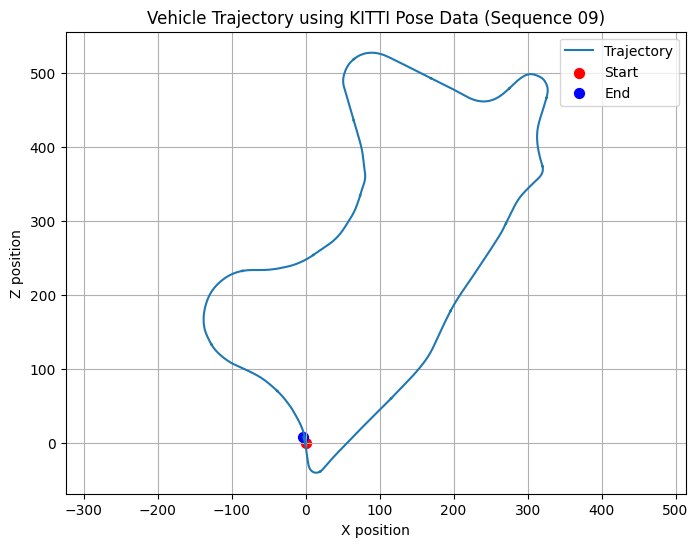

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# KITTI sequence 09 pose 데이터 경로
pose_path = "E:/KITTI_dataset/dataset/poses/09.txt"

# pose 데이터 읽기
poses = np.loadtxt(pose_path)

# KITTI pose는 각 행이 3x4 변환행렬을 펼친 형태
# [r11 r12 r13 tx r21 r22 r23 ty r31 r32 r33 tz]
# 여기서 tx, ty, tz가 카메라 위치 성분
x = poses[:, 3]
y = poses[:, 7]
z = poses[:, 11]

# 2D 궤적 시각화: 보통 차량의 수평 이동은 X-Z 평면에서 확인
plt.figure(figsize=(8, 6))

plt.plot(x, z, label="Trajectory")

# 시작점과 끝점 표시
plt.scatter(x[0], z[0], c='red', label='Start', s=50)
plt.scatter(x[-1], z[-1], c='blue', label='End', s=50)

# 이동 방향 화살표 표시
for i in range(0, len(x)-1, 100):
    plt.arrow(
        x[i], z[i],
        x[i+1] - x[i],
        z[i+1] - z[i],
        head_width=2,
        head_length=3,
        fc='green',
        ec='green'
    )

plt.xlabel("X position")
plt.ylabel("Z position")
plt.title("Vehicle Trajectory using KITTI Pose Data (Sequence 09)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

KITTI Sequence 09의 pose 데이터를 이용하여 차량의 이동 궤적을 시각화하였다. KITTI의 pose 파일은 각 프레임마다 카메라 좌표계의 위치와 방향 정보를 포함하고 있으며, 각 행은 하나의 프레임에 대한 3x4 변환 행렬 형태로 구성되어 있다.

이 변환 행렬에서 네 번째 열에 해당하는 값들을 이용하면 각 프레임에서의 카메라 위치를 추출할 수 있다. 여기서 X축은 차량의 좌우 방향, Z축은 차량의 전진 방향을 의미하므로, 차량의 주행 경로는 X-Z 평면 위에 표현하였다.

본 실험에서는 첫 번째 프레임의 위치를 기준점으로 설정하고, 이후 프레임들의 위치를 상대 좌표로 나타내었다. 이를 통해 차량이 초기 위치에서 출발하여 시간에 따라 어떤 방향으로 이동했는지 확인할 수 있도록 하였다.

시각화 결과, 그래프에서 빨간 점은 주행 시작 지점, 파란 점은 주행 종료 지점을 나타낸다. 전체 궤적을 보면 차량은 초기 위치에서 출발하여 전반적으로 전진 방향으로 이동하였고, 중간중간 방향이 바뀌는 곡선 형태의 경로를 보였다. 이는 실제 주행 과정에서 직선 도로뿐만 아니라 회전 구간이나 도로 방향이 변하는 구간이 포함되어 있음을 의미한다.

또한 궤적의 곡률이 크게 변하는 부분은 차량이 회전했거나 도로의 방향이 달라진 구간으로 해석할 수 있다. 반대로 비교적 완만하고 직선에 가까운 부분은 차량이 일정한 방향으로 주행한 구간으로 볼 수 있다.

차량의 속도는 프레임 사이의 위치 변화량을 통해 간접적으로 추정할 수 있다. 프레임 간 이동 거리가 큰 구간은 상대적으로 빠르게 이동한 구간으로 볼 수 있고, 이동 거리가 작은 구간은 감속하거나 회전이 발생한 구간으로 해석할 수 있다. 따라서 pose 데이터를 이용하면 단순히 차량의 이동 경로뿐만 아니라 주행 방향과 상대적인 속도 변화도 함께 파악할 수 있다.

이러한 pose 기반 궤적 정보는 이후 차선 또는 도로 영역 분류 결과를 분석할 때도 활용될 수 있다. 특히 차량이 회전하거나 도로 방향이 급격히 바뀌는 구간에서는 고정된 사다리꼴 ROI가 실제 도로 영역과 어긋날 수 있다. 따라서 이러한 구간에서는 Bayesian 분류 결과가 불안정해지거나 도로 영역이 잘못 검출될 가능성이 있다.

## 문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과를 이용하여 이미지에서 도로 영역을 추출하였다. 본 과제에서 사용한 Bayesian 분류는 영상의 밝기 정보를 기반으로 도로 영역과 배경 영역을 구분하며, 분류 결과는 도로 가능성이 높은 픽셀 영역으로 나타난다. 따라서 이 도로 영역은 차선 후보가 존재할 가능성이 높은 영역으로 해석할 수 있다.

이미지에서 검출된 차선 후보는 픽셀 좌표 (u, v)로 표현된다. 그러나 실제로 이 점들은 단순한 2차원 점이 아니라, 카메라 앞 3차원 공간의 도로 평면 위에 존재하는 점들이 Projection Matrix에 의해 이미지 평면으로 투영된 결과이다. 즉, 이미지 좌표계에서 보이는 차선 후보는 실제 카메라 좌표계에서는 차량 전방의 도로 평면 위에 놓인 구조로 볼 수 있다.

도로를 ground plane이라고 가정하면, 차선은 이 평면 위에 존재하는 직선 구조로 해석할 수 있다. 실제 3차원 공간에서 좌우 차선은 서로 평행하고 일정한 간격을 유지하지만, 이미지에서는 원근 투영의 영향으로 위쪽으로 갈수록 서로 가까워진다. 이러한 특성 때문에 도로 영역은 이미지 하단에서는 넓게 나타나고, 멀어질수록 좁아지며 소실점 방향으로 수렴하는 형태를 보인다.

Projection Matrix는 카메라의 내부 파라미터와 외부 파라미터를 포함하므로, 차선의 이미지상 위치와 기울기는 카메라의 초점 거리, 주점, 자세, 위치에 영향을 받는다. 예를 들어 카메라의 방향이 바뀌거나 차량이 회전하면, 실제 도로 위의 같은 차선이라도 이미지에서는 기울기와 위치가 다르게 나타날 수 있다. 또한 카메라의 자세 변화는 소실점의 위치에도 영향을 주기 때문에, 차선이 수렴하는 방향 역시 달라질 수 있다.

따라서 Projection Matrix는 이미지에서 보이는 차선의 기울기와 소실점이 단순한 2차원 영상 특징이 아니라, 실제 3차원 도로 구조와 카메라 기하가 반영된 결과임을 설명해 준다. Bayesian 분류 결과는 차선 후보가 존재할 가능성이 높은 도로 영역을 제공하고, Projection Matrix는 그 후보 영역이 실제 카메라 좌표계의 도로 평면 위 구조와 어떻게 연결되는지를 해석하는 데 사용된다.

이러한 관계를 역으로 이용하면 이미지 좌표를 위에서 내려다본 형태의 Bird’s Eye View로 변환할 수 있으며, 이는 IPM, 즉 Inverse Perspective Mapping에도 활용될 수 있다. Bird’s Eye View에서는 원근 효과가 줄어들기 때문에 차선의 평행성이나 도로 폭을 더 직관적으로 분석할 수 있다.

## 문제 5 실패 구간 분석

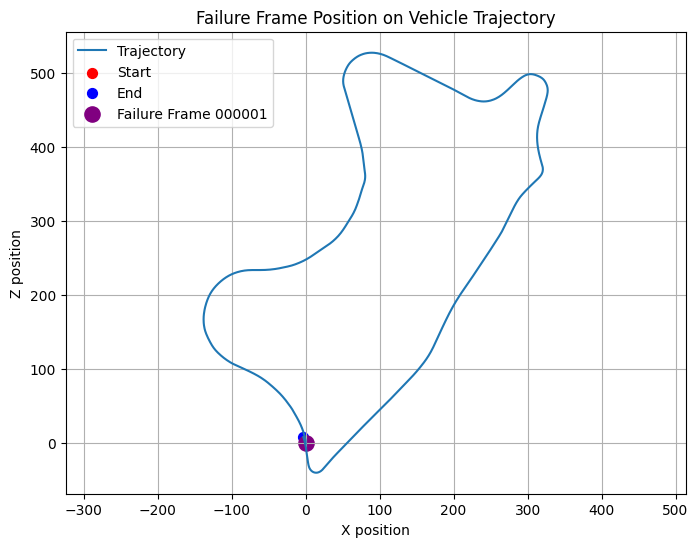

In [6]:
fail_idx = 1

plt.figure(figsize=(8, 6))
plt.plot(x, z, label="Trajectory")
plt.scatter(x[0], z[0], c="red", label="Start", s=50)
plt.scatter(x[-1], z[-1], c="blue", label="End", s=50)

# 실패 프레임 위치 표시
plt.scatter(x[fail_idx], z[fail_idx], c="purple", s=120, label="Failure Frame 000001")

plt.xlabel("X position")
plt.ylabel("Z position")
plt.title("Failure Frame Position on Vehicle Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

![alt text](overlay_000001.png)

**선택한 프레임:** `overlay_000001.png`
차량 궤적 중 Bayesian 분류가 잘 되지 않은 구간으로 overlay_000001.png 프레임을 선택하였다.

선택한 프레임은 sequence 초반부에 위치하며, 궤적 그래프 상에서는 주행 시작점에 가까운 위치에 해당한다. 해당 프레임에서는 Bayesian 분류기가 실제 도로 영역뿐만 아니라 나무, 그림자, 밝은 배경 영역까지 도로로 오분류하는 현상이 나타난다. 특히 빨간색으로 표시된 도로 분류 결과가 도로 하단부를 넘어 이미지 상단의 나무와 그림자 영역까지 넓게 퍼져 있어 False Positive가 많이 발생한 것을 확인할 수 있다.

### 1. 조명 변화 및 그림자의 영향

해당 프레임에서는 도로 주변에 나무와 수풀로 인한 그림자가 많이 존재한다. 본 실험에서 사용한 Bayesian 분류기는 픽셀의 밝기 값, 즉 intensity 분포를 기반으로 도로와 배경을 구분한다. 그런데 그림자 영역의 밝기 분포가 도로 영역과 유사하게 나타나면, 분류기는 해당 영역을 도로로 잘못 판단할 수 있다.

실제로 결과 이미지에서도 도로가 아닌 나무 아래 그림자 영역과 어두운 배경 영역 일부가 도로로 분류되었다. 이는 단순한 밝기 기반 분류 방식이 조명 변화나 그림자에 취약하다는 점을 보여준다.

### 2. 도로 질감 변화와 대비 부족

도로 표면은 항상 일정한 밝기와 질감을 가지지 않는다. 해당 프레임에서도 도로 위의 그림자, 밝게 노출된 영역, 주변 배경의 질감이 함께 나타나면서 도로와 비도로 영역의 경계가 뚜렷하게 구분되지 않는다.

이처럼 도로와 배경 사이의 대비가 낮아지면 픽셀 단위의 확률 기반 분류에서는 경계가 불명확해진다. 그 결과 실제 도로 영역보다 더 넓은 영역이 도로로 분류되거나, 배경 영역이 도로 영역으로 포함되는 문제가 발생한다.

### 3. 차량의 회전 또는 카메라 방향 변화

선택한 프레임은 sequence 초반부에 위치하지만, 차량이 진행하면서 카메라의 방향이나 자세가 조금만 변해도 이미지에서 도로의 위치와 기울기는 달라질 수 있다. 특히 차량이 회전하거나 도로 방향이 바뀌는 구간에서는 실제 도로 영역이 이미지의 정중앙에 고정되어 나타나지 않는다.

이 경우 고정된 사다리꼴 ROI는 실제 도로 영역을 정확히 따라가지 못하고, 일부 배경 영역을 도로 후보 영역으로 포함할 수 있다. 따라서 차량의 회전이나 카메라 방향 변화는 도로 영역 분류가 불안정해지는 원인 중 하나가 된다.

### 4. ROI 사다리꼴 가정의 한계

본 코드에서는 도로가 이미지 하단 중앙에서 시작하여 위쪽으로 갈수록 좁아지는 사다리꼴 형태라고 가정하였다. 이러한 ROI 설정은 차량이 비교적 직진하고 도로가 정면에 놓여 있을 때는 효과적이다.

그러나 실제 주행 영상에서는 도로가 곡선 형태로 나타나거나, 차량의 진행 방향이 바뀌거나, 주변 물체와 그림자가 ROI 내부에 포함될 수 있다. 해당 프레임에서도 고정된 사다리꼴 ROI 안에 도로가 아닌 배경 영역이 함께 포함되면서, Bayesian 분류 결과가 실제 도로 영역보다 넓게 퍼지는 문제가 발생하였다.

### 5. 종합 분석

이 실패 사례는 조명 변화, 그림자, 도로 질감 변화, 차량 진행 방향 변화, 고정 ROI 가정의 한계가 복합적으로 작용한 결과이다. Bayesian 분류기는 intensity 기반의 단순한 통계 모델이기 때문에 도로와 배경의 밝기 분포가 비슷해지는 상황에서는 안정적인 분류가 어렵다.

또한 고정된 사다리꼴 ROI는 도로가 항상 일정한 위치와 형태로 나타난다는 가정에 기반하기 때문에, 곡선 도로 또는 카메라 방향 변화가 있는 구간에서는 실제 도로 구조를 충분히 반영하지 못한다. 따라서 이러한 한계를 보완하기 위해서는 단순 밝기 정보뿐만 아니라 공간적 구조와 문맥 정보를 함께 학습할 수 있는 CNN 기반 딥러닝 모델을 적용하는 것이 더 적절하다고 볼 수 있다.

